*Workflow*
Load train images -> Normalize -> Augment -> Train
Load test images -> Normalize -> Evaluate

In [1]:
from PIL import Image
import numpy as np
import os
import tensorflow as tf
import random
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import gc



gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)


2026-02-19 16:37:41.298651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771515461.330053   12929 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771515461.342979   12929 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771515461.375372   12929 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771515461.375463   12929 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771515461.375469   12929 computation_placer.cc:177] computation placer alr

In [2]:
def load_images(folder):
    images = []
    labels = []
    
    class_names = sorted(os.listdir(folder))
    
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        
        if not os.path.isdir(class_path):
            continue
        
        for file in os.listdir(class_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(class_path, file)
                
                img = Image.open(path)
                img = np.array(img, dtype=np.float32)
                
                images.append(img)
                labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

In [3]:
def augment_image(img):
    # Horizontal flip
    if random.random() > 0.5:
        img = np.fliplr(img)
    
    # Vertical flip
    if random.random() > 0.5:
        img = np.flipud(img)
    
    # Random rotation (90° steps for simplicity)
    k = random.randint(0, 3)
    img = np.rot90(img, k)
    
    return img

def augment_data(X_train, y_train):
    # Extract Ovarian Cancer (OC) class
    X_OC = X_train[y_train == 2]
    y_OC = y_train[y_train == 2]

    # Apply augmentation to training images
    X_OC_aug_1 = np.array([augment_image(img) for img in X_OC])
    X_OC_aug_2 = np.array([augment_image(img) for img in X_OC])
    X_OC_aug_3 = np.array([augment_image(img) for img in X_OC])
    X_OC_aug_4 = np.array([augment_image(img) for img in X_OC])

    # Combine original and augmented data
    X_train = np.concatenate([X_train, X_OC_aug_1, X_OC_aug_2, X_OC_aug_3, X_OC_aug_4])
    y_train = np.concatenate([y_train, y_OC, y_OC, y_OC, y_OC])

    # # Apply augmentation to OC training images again to further balance the dataset
    # X_OC = X_train[y_train == 2]
    # y_OC = y_train[y_train == 2]
    # X_OC_aug_5= np.array([augment_image(img) for img in X_OC])
    # X_OC_aug_6= np.array([augment_image(img) for img in X_OC])
    # X_train = np.concatenate([X_train, X_OC_aug_5, X_OC_aug_6])
    # y_train = np.concatenate([y_train, y_OC, y_OC])

    print(X_train.min(), X_train.max()) # Check normalization
    unique, counts = np.unique(y_train, return_counts=True)
    print(dict(zip(unique, counts))) # Check class distribution after augmentation
    
    return X_train, y_train


In [4]:
def compute_class_weights(y_train):
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights))
    print(class_weights)
    
    return class_weights

In [5]:
def build_and_train_model(X_train, y_train, X_test, y_test, class_weights):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(224,224,1)),

        tf.keras.layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Conv2D(64, (5,5), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax')  # Multi-Class classification (4 classes)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=25,
        batch_size=16,
        class_weight=class_weights,
        verbose=1
    )

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.legend(['Train', 'Validation'])
    plt.show()

    return model, history

In [6]:
# One-Vs-Rest (OvR) Evaluation
def evaluate_model(model, X_test, y_test):
    y_probs = model.predict(X_test)
    y_pred = np.argmax(y_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
    auc_val = roc_auc_score(y_test_bin, y_probs, average='macro')

    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("AUC:", auc_val)
    print("Confusion Matrix:\n", cm)
    return acc, precision, recall, f1, auc_val

In [ ]:
def save_background_data(X_train, y_train):
    background_size_per_class = 10
    background_indices = []

    for class_label in range(4):
        class_indices = np.where(y_train == class_label)[0]
        selected = np.random.choice(class_indices, background_size_per_class, replace=False)
        background_indices.extend(selected)

    background_data = X_train[background_indices]
    np.save("background_data.npy", background_data)
    print("Background data saved for SHAP explanations.")


=========== FOLD 1 ===========
0.0 1.0
{np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(210), np.int64(3): np.int64(400)}
{0: np.float64(0.88125), 1: np.float64(0.88125), 2: np.float64(1.6785714285714286), 3: np.float64(0.88125)}


I0000 00:00:1771515494.585319   12929 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/25


I0000 00:00:1771515500.003619   13133 service.cc:152] XLA service 0x7d31dc029d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771515500.003699   13133 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-19 16:38:20.120010: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771515500.457537   13133 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/89 ━━━━━━━━━━━━━━━━━━━━ 16:09 11s/step - accuracy: 0.1875 - loss: 1.3653

I0000 00:00:1771515509.093786   13133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


89/89 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - accuracy: 0.7284 - loss: 0.7713 - val_accuracy: 0.9132 - val_loss: 0.2784
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8823 - loss: 0.3535 - val_accuracy: 0.9325 - val_loss: 0.2089
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9248 - loss: 0.2339 - val_accuracy: 0.9325 - val_loss: 0.1638
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9440 - loss: 0.1768 - val_accuracy: 0.9357 - val_loss: 0.1524
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9532 - loss: 0.1448 - val_accuracy: 0.9486 - val_loss: 0.1556
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9596 - loss: 0.1249 - val_accuracy: 0.9421 - val_loss: 0.1538
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9702 - loss: 0.1055 - val_accuracy: 0.9518 - val_loss: 0.1441
Epoch 8/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9752 - loss: 0.0895 - val_accuracy: 0.9486 - val_loss: 

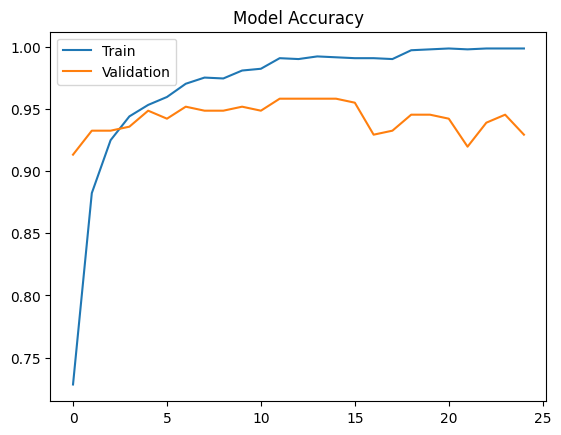

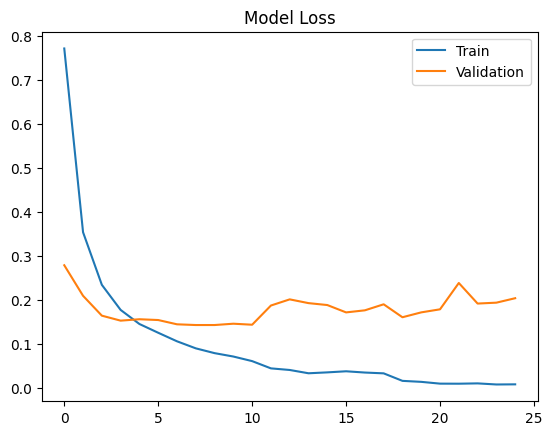

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step
Accuracy: 0.9292604501607717
Precision: 0.8088717228464419
Recall: 0.864090909090909
F1-score: 0.8197096594081519
AUC: 0.9779753698118627
Confusion Matrix:
 [[84  0 16  0]
 [ 1 99  0  0]
 [ 4  0  7  0]
 [ 0  0  1 99]]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

=========== FOLD 2 ===========
0.0 1.0
{np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(210), np.int64(3): np.int64(400)}
{0: np.float64(0.88125), 1: np.float64(0.88125), 2: np.float64(1.6785714285714286), 3: np.float64(0.88125)}
Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.7383 - loss: 0.7616 - val_accuracy: 0.9260 - val_loss: 0.2656
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8872 - loss: 0.3421 - val_accuracy: 0.9325 - val_loss: 0.2153
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9312 - loss: 0.2280 - val_accuracy: 0.9486 - val_loss: 0.1786
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accur

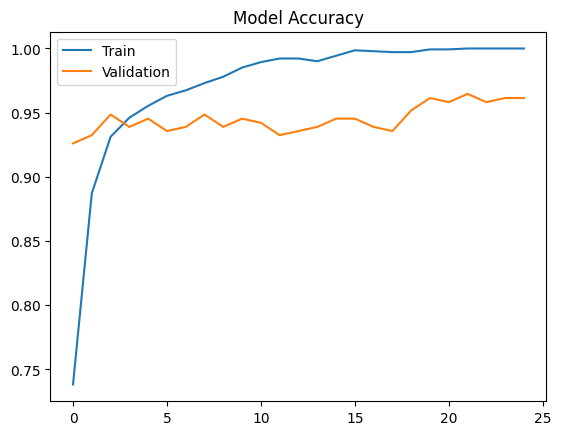

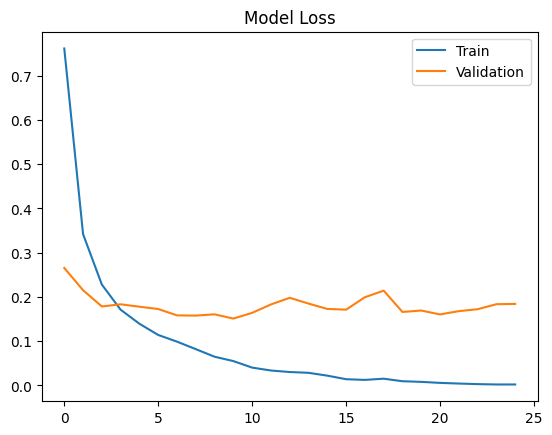

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Accuracy: 0.9614147909967846
Precision: 0.8580097087378641
Recall: 0.8486363636363636
F1-score: 0.8529755684928099
AUC: 0.9871786586241562
Confusion Matrix:
 [[ 96   0   4   0]
 [  1  98   1   0]
 [  6   0   5   0]
 [  0   0   0 100]]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=========== FOLD 3 ===========
0.0 1.0
{np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(210), np.int64(3): np.int64(400)}
{0: np.float64(0.88125), 1: np.float64(0.88125), 2: np.float64(1.6785714285714286), 3: np.float64(0.88125)}
Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.7170 - loss: 0.7886 - val_accuracy: 0.9357 - val_loss: 0.2248
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8922 - loss: 0.3400 - val_accuracy: 0.9518 - val_loss: 0.1532
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9234 - loss: 0.2362 - val_accuracy: 0.9421 - val_loss: 0.1369
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 4

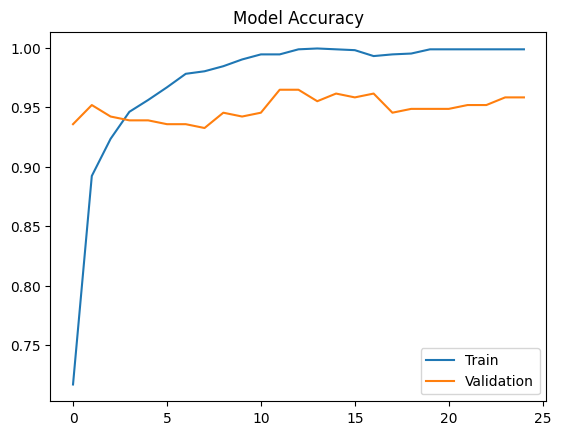

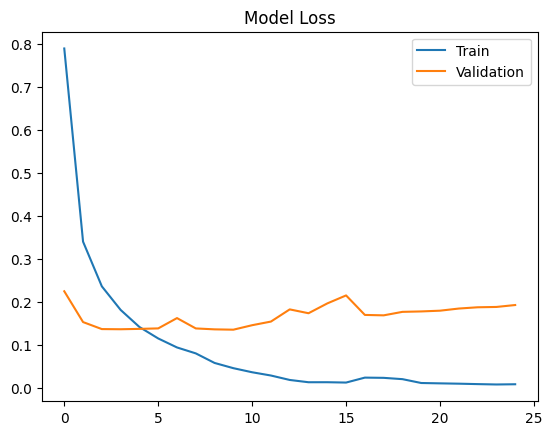

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
Accuracy: 0.9581993569131833
Precision: 0.8330097087378641
Recall: 0.8259090909090909
F1-score: 0.8291787343944682
AUC: 0.9653802240413615
Confusion Matrix:
 [[96  0  4  0]
 [ 0 99  1  0]
 [ 7  0  4  0]
 [ 0  0  1 99]]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=========== FOLD 4 ===========
0.0 1.0
{np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(215), np.int64(3): np.int64(400)}
{0: np.float64(0.884375), 1: np.float64(0.884375), 2: np.float64(1.6453488372093024), 3: np.float64(0.884375)}
Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.6968 - loss: 0.7604 - val_accuracy: 0.8903 - val_loss: 0.3265
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8848 - loss: 0.3338 - val_accuracy: 0.9194 - val_loss: 0.2304
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9293 - loss: 0.2205 - val_accuracy: 0.9258 - val_loss: 0.1986
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - a

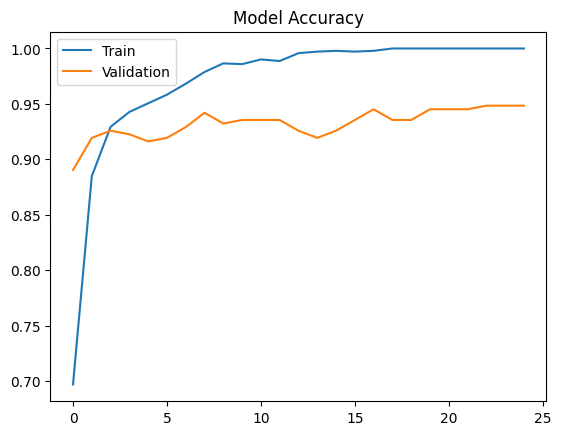

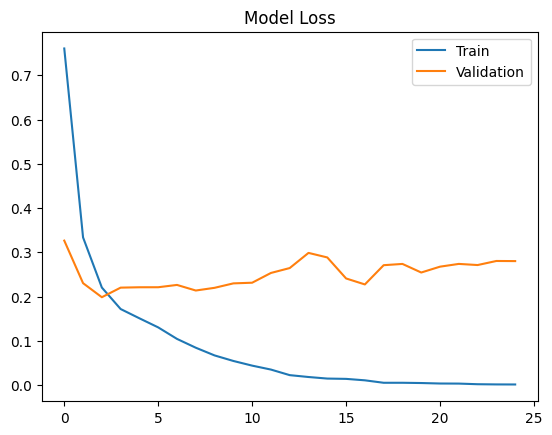

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step
Accuracy: 0.9483870967741935
Precision: 0.8185818581858186
Recall: 0.825
F1-score: 0.8215562531920442
AUC: 0.9832857142857143
Confusion Matrix:
 [[93  1  6  0]
 [ 2 98  0  0]
 [ 6  0  4  0]
 [ 0  0  1 99]]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

=========== FOLD 5 ===========
0.0 1.0
{np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(215), np.int64(3): np.int64(400)}
{0: np.float64(0.884375), 1: np.float64(0.884375), 2: np.float64(1.6453488372093024), 3: np.float64(0.884375)}
Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.6940 - loss: 0.7768 - val_accuracy: 0.9097 - val_loss: 0.2762
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8813 - loss: 0.3553 - val_accuracy: 0.8742 - val_loss: 0.2894
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9216 - loss: 0.2536 - val_accuracy: 0.8903 - val_loss: 0.2547
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.93

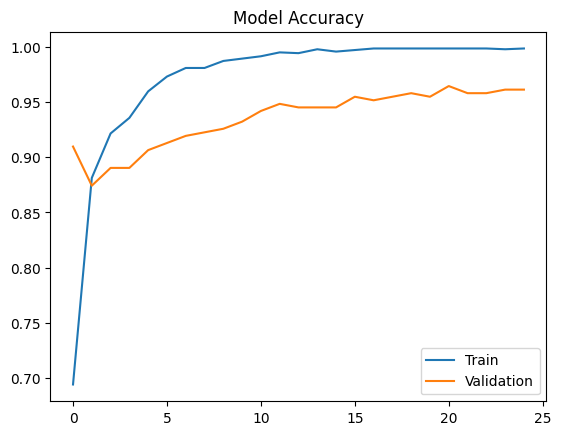

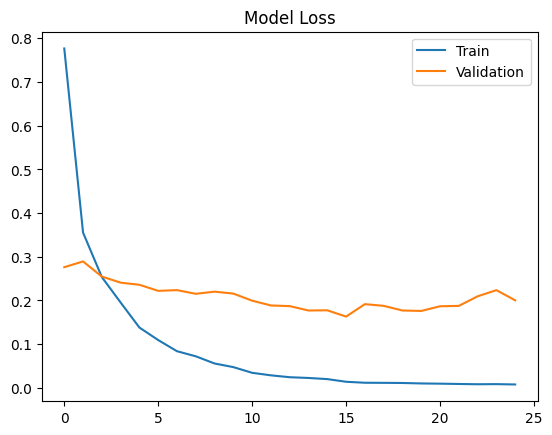

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
Accuracy: 0.9612903225806452
Precision: 0.8580097087378641
Recall: 0.8575
F1-score: 0.8576716680381556
AUC: 0.9737440476190476
Confusion Matrix:
 [[96  0  4  0]
 [ 0 99  1  0]
 [ 5  0  5  0]
 [ 2  0  0 98]]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

===== FINAL CROSS VALIDATION RESULTS =====
Mean Accuracy: 0.9517104034851156
Mean Precision: 0.8352965414491706
Mean Recall: 0.8442272727272726
Mean F1: 0.8362183767051258
Mean AUC: 0.9775128028764284


In [ ]:
best_recall = -1
best_fold = None
best_model_path = "aocdml.keras"


# Loop through each fold and train/evaluate the model
all_fold_results = []
all_y_true = []
all_y_prob = []
for fold in range(1, 6):
    print(f"\n=========== FOLD {fold} ===========")
    tf.keras.backend.clear_session()
    train_dir = rf"cross_val_folds/fold_{fold}/train"
    test_dir = rf"cross_val_folds/fold_{fold}/test"

    # Load images and labels
    X_train, y_train = load_images(train_dir)
    X_test, y_test = load_images(test_dir)

    # Normalize image data
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Add channel dimension
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    # Augment training data
    X_train, y_train = augment_data(X_train, y_train)
   
    # Compute class weights
    class_weights = compute_class_weights(y_train)
   
    # Build and compile model
    model, history = build_and_train_model(X_train, y_train, X_test, y_test, class_weights)
   
    # Evaluate and save model
    acc, precision, recall, f1, auc_val = evaluate_model(model, X_test, y_test)
    if recall > best_recall:
        print(f"New best model found at fold {fold} (Recall = {recall:.4f})")
        best_recall = recall
        best_fold = fold
        model.save(best_model_path)
        save_background_data(X_train, y_train)
    all_fold_results.append([acc, precision, recall, f1, auc_val])
   
    # Store true labels and predicted probabilities for ROC curve analysis
    y_prob = model.predict(X_test)
    all_y_true.append(y_test)
    all_y_prob.append(y_prob)

    del X_train, y_train, X_test, y_test, model, history
    gc.collect()
    
    # Optional: reset GPU memory stats
    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except:
        pass
   
# Print average results across folds
all_fold_results = np.array(all_fold_results)
y_true_all = np.concatenate(all_y_true)
y_prob_all = np.concatenate(all_y_prob)
print("\n===== FINAL CROSS VALIDATION RESULTS =====")
print("Mean Accuracy:", all_fold_results[:,0].mean())
print("Mean Precision:", all_fold_results[:,1].mean())
print("Mean Recall:", all_fold_results[:,2].mean())
print("Mean F1:", all_fold_results[:,3].mean())
print("Mean AUC:", all_fold_results[:,4].mean())
print(f"\nBest model was from Fold {best_fold} with recall = {best_recall:.4f}")
print(f"Saved as: {best_model_path}")


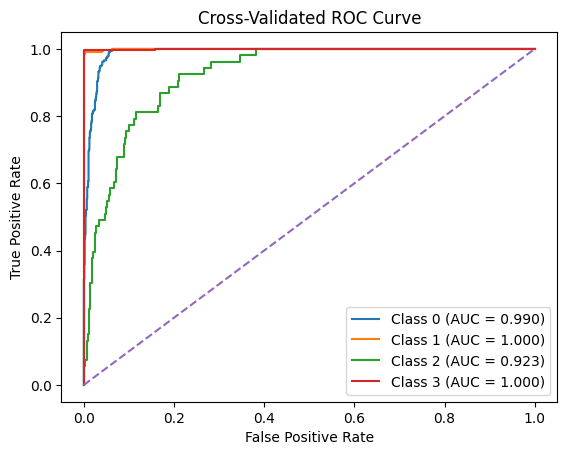

In [8]:
n_classes = 4
y_true_bin = label_binarize(y_true_all, classes=[0,1,2,3])

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curve")
plt.legend()
plt.show()

In [ ]:
# fpr, tpr, _ = roc_curve(y_true, y_score)
# roc_auc = auc(fpr, tpr)

# plt.figure()
# plt.plot(fpr, tpr)
# plt.plot([0, 1], [0, 1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
# plt.show()

# print("AUC:", roc_auc)

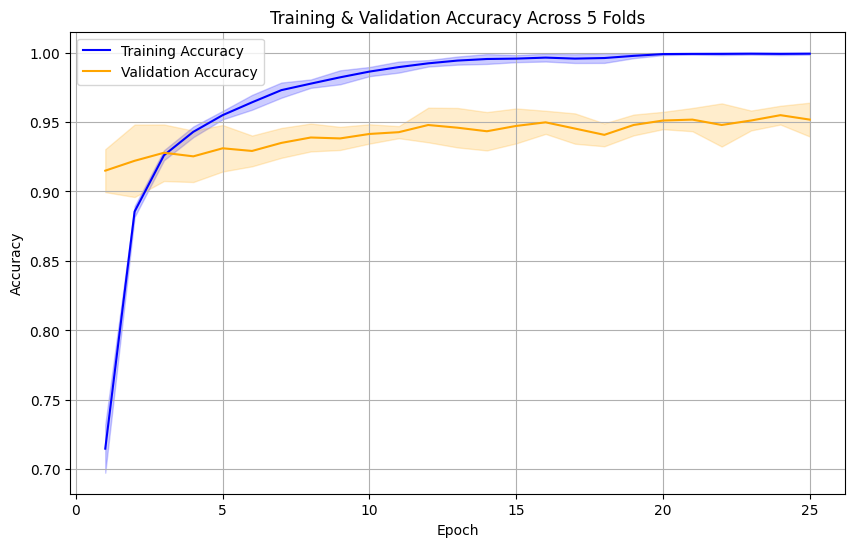

In [9]:
# Training Accuracy and Validation Accuracy Plotting
train_acc_folds = [
    [0.7284, 0.8823, 0.9248, 0.944, 0.9532, 0.9596, 0.9702, 0.9752, 0.9745, 0.9809, 0.9823, 0.9908, 0.9901, 0.9922, 0.9915, 0.9908, 0.9908, 0.9901, 0.9972, 0.9979, 0.9986, 0.9979, 0.9986, 0.9986, 0.9986],
    [0.7383, 0.8872, 0.9312, 0.9461, 0.9553, 0.9631, 0.9674, 0.973, 0.978, 0.9851, 0.9894, 0.9922, 0.9922, 0.9901, 0.9943, 0.9986, 0.9979, 0.9972, 0.9972, 0.9993, 0.9993, 1.0, 1.0, 1.0, 1.0],
    [0.717, 0.8922, 0.9234, 0.9461, 0.956, 0.9667, 0.978, 0.9801, 0.9844, 0.9901, 0.9943, 0.9943, 0.9986, 0.9993, 0.9986, 0.9979, 0.9929, 0.9943, 0.995, 0.9986, 0.9986, 0.9986, 0.9986, 0.9986, 0.9986],
    [0.6968, 0.8848, 0.9293, 0.9428, 0.9505, 0.9583, 0.9682, 0.9788, 0.9866, 0.9859, 0.9901, 0.9887, 0.9958, 0.9972, 0.9979, 0.9972, 0.9979, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    [0.694, 0.8813, 0.9216, 0.9357, 0.9597, 0.9731, 0.9809, 0.9809, 0.9873, 0.9894, 0.9915, 0.9951, 0.9943, 0.9979, 0.9958, 0.9972, 0.9986, 0.9986, 0.9986, 0.9986, 0.9986, 0.9986, 0.9986, 0.9979, 0.9986],
]

val_acc_folds = [
    [0.9132, 0.9325, 0.9325, 0.9357, 0.9486, 0.9421, 0.9518, 0.9486, 0.9486, 0.9518, 0.9486, 0.9582, 0.9582, 0.9582, 0.9582, 0.955, 0.9293, 0.9325, 0.9453, 0.9453, 0.9421, 0.9196, 0.9389, 0.9453, 0.9293],
    [0.926, 0.9325, 0.9486, 0.9389, 0.9453, 0.9357, 0.9389, 0.9486, 0.9389, 0.9453, 0.9421, 0.9325, 0.9357, 0.9389, 0.9453, 0.9453, 0.9389, 0.9357, 0.9518, 0.9614, 0.9582, 0.9646, 0.9582, 0.9614, 0.9614],
    [0.9357, 0.9518, 0.9421, 0.9389, 0.9389, 0.9357, 0.9357, 0.9325, 0.9453, 0.9421, 0.9453, 0.9646, 0.9646, 0.955, 0.9614, 0.9582, 0.9614, 0.9453, 0.9486, 0.9486, 0.9486, 0.9518, 0.9518, 0.9582, 0.9582],
    [0.8903, 0.9194, 0.9258, 0.9226, 0.9161, 0.9194, 0.929, 0.9419, 0.9323, 0.9355, 0.9355, 0.9355, 0.9258, 0.9194, 0.9258, 0.9355, 0.9452, 0.9355, 0.9355, 0.9452, 0.9452, 0.9452, 0.9484, 0.9484, 0.9484],
    [0.9097, 0.8742, 0.8903, 0.8903, 0.9065, 0.9129, 0.9194, 0.9226, 0.9258, 0.9323, 0.9419, 0.9484, 0.9452, 0.9452, 0.9452, 0.9548, 0.9516, 0.9548, 0.9581, 0.9548, 0.9645, 0.9581, 0.9581, 0.9613, 0.9613],
]


# Convert to numpy arrays for easy calculation
train_acc_folds = np.array(train_acc_folds)
val_acc_folds = np.array(val_acc_folds)

# Compute mean and std per epoch
train_mean = train_acc_folds.mean(axis=0)
train_std = train_acc_folds.std(axis=0)
val_mean = val_acc_folds.mean(axis=0)
val_std = val_acc_folds.std(axis=0)

epochs = np.arange(1, 26)

# Plot with shaded std
plt.figure(figsize=(10,6))
plt.plot(epochs, train_mean, label='Training Accuracy', color='blue')
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(epochs, val_mean, label='Validation Accuracy', color='orange')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Across 5 Folds')
plt.legend()
plt.grid(True)
plt.show()

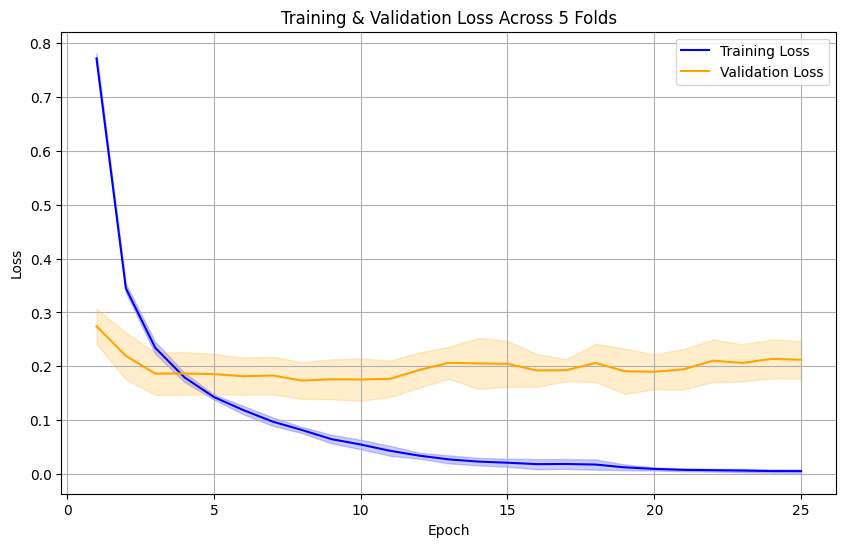

In [10]:
# Training Loss and Validation Loss Plotting
train_loss_folds = [
    [0.7713, 0.3535, 0.2339, 0.1768, 0.1448, 0.1249, 0.1055, 0.0895, 0.0786, 0.0709, 0.0604, 0.0439, 0.0403, 0.0328, 0.0348, 0.0373, 0.0344, 0.0326, 0.0155, 0.0133, 0.0092, 0.0091, 0.0098, 0.0073, 0.0076],
    [0.7616, 0.3421, 0.228, 0.1712, 0.1395, 0.1141, 0.099, 0.0821, 0.0649, 0.0551, 0.0404, 0.0338, 0.0304, 0.0286, 0.0222, 0.0141, 0.0126, 0.0153, 0.0096, 0.0081, 0.0058, 0.0043, 0.003, 0.0022, 0.0022],
    [0.7886, 0.34, 0.2362, 0.1815, 0.1418, 0.1152, 0.0943, 0.0805, 0.0583, 0.0462, 0.0367, 0.0291, 0.0188, 0.0135, 0.0136, 0.0128, 0.0242, 0.0237, 0.0207, 0.0117, 0.0109, 0.0102, 0.0092, 0.0083, 0.0088],
    [0.7604, 0.3338, 0.2205, 0.172, 0.151, 0.1305, 0.1045, 0.0846, 0.0672, 0.0547, 0.0442, 0.0353, 0.0227, 0.0185, 0.0149, 0.0142, 0.011, 0.0054, 0.0054, 0.0049, 0.0038, 0.0036, 0.0022, 0.0017, 0.0016],
    [0.7768, 0.3553, 0.2536, 0.1953, 0.138, 0.1094, 0.0839, 0.0722, 0.0558, 0.0475, 0.0345, 0.0287, 0.0243, 0.0227, 0.02, 0.0139, 0.0117, 0.0115, 0.0112, 0.0101, 0.0096, 0.0089, 0.0083, 0.0085, 0.0077],
]

val_loss_folds = [
    [0.2784, 0.2089, 0.1638, 0.1524, 0.1556, 0.1538, 0.1441, 0.1425, 0.1425, 0.1455, 0.1432, 0.1868, 0.2008, 0.1923, 0.1879, 0.1712, 0.1759, 0.1896, 0.1602, 0.1713, 0.1782, 0.2381, 0.1913, 0.1933, 0.2035],
    [0.2656, 0.2153, 0.1786, 0.1834, 0.178, 0.1728, 0.1584, 0.1579, 0.1608, 0.1512, 0.1641, 0.1831, 0.1981, 0.1851, 0.1729, 0.1713, 0.1994, 0.2143, 0.1661, 0.1694, 0.1605, 0.168, 0.1724, 0.1837, 0.1843],
    [0.2248, 0.1532, 0.1369, 0.1366, 0.1374, 0.1385, 0.1625, 0.1385, 0.1363, 0.1355, 0.146, 0.1544, 0.1827, 0.1738, 0.1966, 0.2151, 0.1698, 0.1688, 0.1769, 0.1779, 0.1797, 0.1846, 0.1876, 0.1884, 0.1928],
    [0.3265, 0.2304, 0.1986, 0.2203, 0.2211, 0.2212, 0.2264, 0.2138, 0.2199, 0.2299, 0.2314, 0.2534, 0.2645, 0.2987, 0.2885, 0.241, 0.2275, 0.271, 0.2738, 0.2545, 0.2677, 0.2739, 0.2713, 0.2805, 0.2802],
    [0.2762, 0.2894, 0.2547, 0.2408, 0.2359, 0.222, 0.2237, 0.2153, 0.2202, 0.2158, 0.1995, 0.1886, 0.1871, 0.177, 0.1775, 0.1631, 0.1916, 0.1877, 0.1771, 0.1761, 0.1867, 0.1876, 0.2095, 0.2236, 0.2003],
]

# Convert to numpy arrays for easy calculation
train_loss_folds = np.array(train_loss_folds)
val_loss_folds = np.array(val_loss_folds)

# Compute mean and std per epoch
train_mean = train_loss_folds.mean(axis=0)
train_std = train_loss_folds.std(axis=0)
val_mean = val_loss_folds.mean(axis=0)
val_std = val_loss_folds.std(axis=0)

epochs = np.arange(1, 26)

# Plot with shaded std
plt.figure(figsize=(10,6))
plt.plot(epochs, train_mean, label='Training Loss', color='blue')
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(epochs, val_mean, label='Validation Loss', color='orange')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Across 5 Folds')
plt.legend()
plt.grid(True)
plt.show()


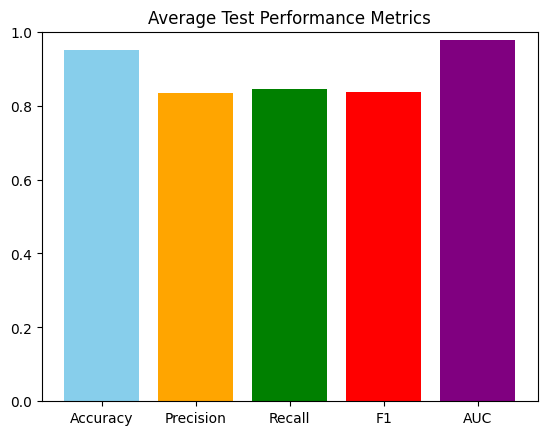

In [12]:
# Test Performance Metrics Plotting

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
values = [0.9517, 0.8352, 0.8442, 0.8362, 0.9775]

plt.bar(metrics, values, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylim(0, 1)
plt.title("Average Test Performance Metrics")
plt.show()


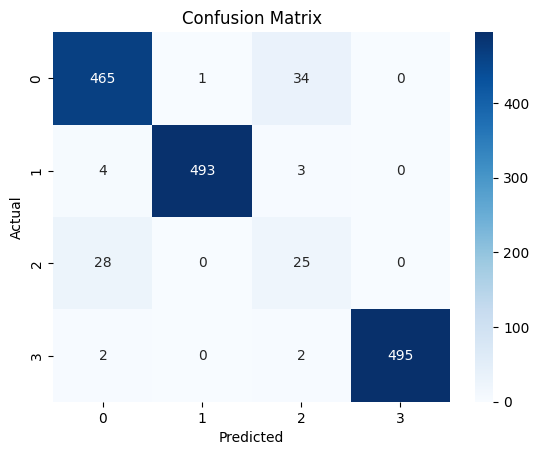

In [14]:
# Confusion Matrix Plotting
cm = np.array([[465,   1,  34,   0],
               [  4, 493,   3,   0],
               [ 28,   0,  25,   0],
               [  2,   0,   2, 495]])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


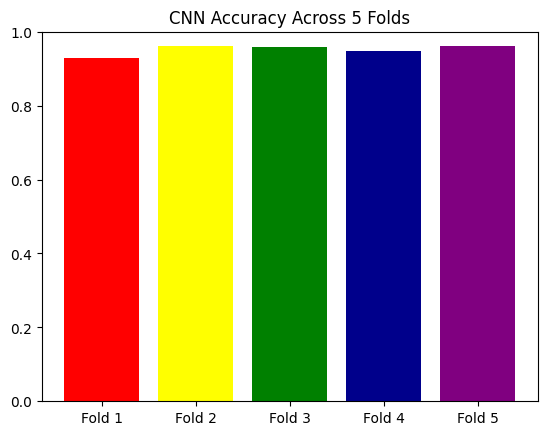

In [15]:
# Cross Validation Accuracy Plotting

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
accuracy = [0.9293, 0.9614, 0.9582, 0.9484, 0.9613]

plt.bar(folds, accuracy, color=['red', 'yellow', 'green', 'darkblue', 'purple'])
plt.ylim(0, 1)
plt.title("CNN Accuracy Across 5 Folds")
plt.show()
